# Transformer — IDX Stock Price Prediction

Google Colab notebook with diagnostics for model analysis.

Outputs include:
- MAE, MSE, RMSE, MAPE
- R² and NRMSE
- Prediction bias
- Directional accuracy
- Naive persistence baseline
- Improvement vs naive baseline
- Best epoch and training/validation loss gap
- Evaluation tables and plots

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    Embedding
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

ROOT = Path("/content")

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Data parameters
FEATURES = ["open", "high", "low", "close", "Volume"]
TARGET_INDEX = 3

# Same main training settings as LSTM
WINDOW_SIZE = 30
EPOCHS = 100
BATCH_SIZE = 32
PATIENCE = 10

# Transformer parameters
D_MODEL = 32
NUM_HEADS = 2
FF_DIM = 64
NUM_LAYERS = 1
DROPOUT = 0.10

print("Transformer Parameters")
print("-" * 35)
print(f"Window Size : {WINDOW_SIZE}")
print(f"d_model     : {D_MODEL}")
print(f"Heads       : {NUM_HEADS}")
print(f"FF Dim      : {FF_DIM}")
print(f"Layers      : {NUM_LAYERS}")
print(f"Dropout     : {DROPOUT}")
print(f"Epochs      : {EPOCHS}")
print(f"Batch Size  : {BATCH_SIZE}")

Transformer Parameters
-----------------------------------
Window Size : 30
d_model     : 32
Heads       : 2
FF Dim      : 64
Layers      : 1
Dropout     : 0.1
Epochs      : 100
Batch Size  : 32


In [3]:
def split(dataset):
    n = len(dataset)

    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    training = dataset.iloc[:train_end]
    validation = dataset.iloc[train_end:val_end]
    testing = dataset.iloc[val_end:]

    return training, validation, testing


def minmax_scaling(training, validation, testing):
    scaler = MinMaxScaler()

    training_scaled = scaler.fit_transform(training)
    validation_scaled = scaler.transform(validation)
    testing_scaled = scaler.transform(testing)

    return (
        training_scaled,
        validation_scaled,
        testing_scaled,
        scaler
    )


def create_windows(scaled_dataset, raw_close, window_size):
    X, y = [], []

    for i in range(len(scaled_dataset) - window_size):

        X.append(
            scaled_dataset[i:i + window_size]
        )

        current_close = raw_close[i + window_size - 1]
        next_close = raw_close[i + window_size]

        log_return = np.log(
            next_close / current_close
        )

        y.append(log_return)

    return np.array(X), np.array(y)


def evaluate(predictions, actuals):
    mae = mean_absolute_error(actuals, predictions)
    mse = mean_squared_error(actuals, predictions)
    rmse = np.sqrt(mse)

    mape = mean_absolute_percentage_error(
        actuals,
        predictions
    ) * 100

    r2 = r2_score(actuals, predictions)

    nrmse = (
        rmse / np.mean(actuals)
    ) * 100

    bias = np.mean(
        predictions - actuals
    )

    return mae, mse, rmse, mape, r2, nrmse, bias

In [4]:
def transformer_block(x):
    attention = MultiHeadAttention(
        num_heads=NUM_HEADS,
        key_dim=D_MODEL // NUM_HEADS,
        dropout=DROPOUT
    )(x, x)

    x = LayerNormalization(epsilon=1e-6)(
        x + Dropout(DROPOUT)(attention)
    )

    ff = Dense(
        FF_DIM,
        activation="relu"
    )(x)

    ff = Dropout(DROPOUT)(ff)
    ff = Dense(D_MODEL)(ff)

    return LayerNormalization(epsilon=1e-6)(
        x + ff
    )


def build_transformer():
    inputs = Input(
        shape=(WINDOW_SIZE, len(FEATURES))
    )

    x = Dense(D_MODEL)(inputs)

    positions = tf.range(
        start=0,
        limit=WINDOW_SIZE
    )

    position_embedding = Embedding(
        input_dim=WINDOW_SIZE,
        output_dim=D_MODEL
    )(positions)

    x = x + position_embedding

    for _ in range(NUM_LAYERS):
        x = transformer_block(x)

    x = x[:, -1, :]
    x = Dense(32, activation="relu")(x)
    x = Dropout(DROPOUT)(x)

    outputs = Dense(1)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=5e-4),
        loss=tf.keras.losses.Huber()
    )

    return model

In [5]:
model = build_transformer()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 32)    │        192 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 32)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 32)    │      4,224 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 32)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 32)    │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 32)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      1,056 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,825 (38.38 KB)

 Trainable params: 9,825 (38.38 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
tickers = sorted([
    f.name
    for f in ROOT.glob("*.csv")
])

print(f"Found {len(tickers)} datasets:")
print(tickers)

Found 12 datasets:
['ADRO.csv', 'BBCA.csv', 'BBNI.csv', 'BBRI.csv', 'BBTN.csv', 'BMRI.csv', 'ITMG.csv', 'MEDC.csv', 'PGAS.csv', 'PTBA.csv', 'Transformer_diagnostics.csv', 'Transformer_evaluation.csv']


In [7]:
results = []
predictions_store = {}
histories = {}

for ticker in tickers:

    ticker_name = ticker.replace(".csv", "")

    print("=" * 60)
    print(f"Training Transformer - {ticker_name}")
    print("=" * 60)

    # Load
    dataset = pd.read_csv(
        ROOT / ticker,
        parse_dates=["time"],
        index_col="time"
    )

    dataset = dataset.sort_index()

    assert dataset.index.is_monotonic_increasing
    assert not dataset.index.duplicated().any()

    dataset = dataset[FEATURES].copy()

    dataset["Volume"] = np.log1p(
        dataset["Volume"]
    )

    training, validation, testing = split(dataset)

    # Scale
    (
        training_scaled,
        validation_scaled,
        testing_scaled,
        scaler
    ) = minmax_scaling(
        training,
        validation,
        testing
    )

    # Windows
    X_train, y_train = create_windows(
        training_scaled,
        training["close"].values,
        WINDOW_SIZE
    )

    X_val, y_val = create_windows(
        validation_scaled,
        validation["close"].values,
        WINDOW_SIZE
    )

    # Give testing data preceding context
    bridge_scaled = np.concatenate([
        validation_scaled[-WINDOW_SIZE:],
        testing_scaled
    ])

    bridge_close = np.concatenate([
        validation["close"].values[-WINDOW_SIZE:],
        testing["close"].values
    ])

    X_test, y_test = create_windows(
        bridge_scaled,
        bridge_close,
        WINDOW_SIZE
    )

    print("Train:", X_train.shape)
    print("Validation:", X_val.shape)
    print("Test:", X_test.shape)

    # Build
    model = build_transformer()

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True
    )

    # Train
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        shuffle=False,
        verbose=0
    )

    histories[ticker_name] = history.history

    # Training diagnostics
    epochs_trained = len(history.history["loss"])
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
    best_val_loss = float(np.min(history.history["val_loss"]))
    train_loss_at_best = float(history.history["loss"][best_epoch - 1])
    loss_gap = float(best_val_loss - train_loss_at_best)

    # Predict
    predictions = model.predict(X_test, verbose=0)

    # Inverse transform predictions
    predicted_returns = predictions[:, 0]
    actual_returns = y_test

    previous_close = bridge_close[WINDOW_SIZE - 1:-1]

    real_predictions = (previous_close * np.exp(predicted_returns))

    real_actuals = (previous_close * np.exp(actual_returns))

    # Sanity check: reconstructed targets must match
    # the original test closing prices
    assert len(real_actuals) == len(testing)

    assert np.allclose(
        real_actuals,
        testing["close"].values,
        rtol=1e-5,
        atol=1e-5
    ), "ERROR: Test target reconstruction is misaligned!"

    print("Target reconstruction check: PASSED")

    # Transformer evaluation
    (
        mae,
        mse,
        rmse,
        mape,
        r2,
        nrmse,
        bias
    ) = evaluate(real_predictions, real_actuals)

    # Directional accuracy
    actual_direction = np.sign(actual_returns)

    predicted_direction = np.sign(predicted_returns)

    directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

    # Naive persistence baseline
    naive_predictions = previous_close

    (
        naive_mae,
        naive_mse,
        naive_rmse,
        naive_mape,
        naive_r2,
        naive_nrmse,
        naive_bias
    ) = evaluate(naive_predictions, real_actuals)

    rmse_improvement = (
        (naive_rmse - rmse) / naive_rmse
    ) * 100

    mape_improvement = (
        (naive_mape - mape) / naive_mape
    ) * 100

    results.append({
        "ticker": ticker_name,
        "model": "Transformer",

        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
        "NRMSE (%)": nrmse,
        "Bias": bias,
        "Directional Accuracy (%)": directional_accuracy,

        "Naive MAE": naive_mae,
        "Naive RMSE": naive_rmse,
        "Naive MAPE": naive_mape,

        "RMSE Improvement (%)": rmse_improvement,
        "MAPE Improvement (%)": mape_improvement,

        "Epochs Trained": epochs_trained,
        "Best Epoch": best_epoch,
        "Best Val Loss": best_val_loss,
        "Train Loss @ Best": train_loss_at_best,
        "Loss Gap": loss_gap,

        "parameter": (
            f"window = {WINDOW_SIZE}, "
            f"d_model = {D_MODEL}, "
            f"heads = {NUM_HEADS}, "
            f"ff_dim = {FF_DIM}, "
            f"layers = {NUM_LAYERS}, "
            f"dropout = {DROPOUT}"
        )
    })

    predictions_store[ticker_name] = {
        "dates": testing.index,
        "actual": real_actuals,
        "predicted": real_predictions,
        "naive": naive_predictions,
        "dataset": dataset
    }

    print()
    print(f"RESULTS - {ticker_name}")
    print("-" * 50)

    print(f"MAE                 : {mae:.4f}")
    print(f"RMSE                : {rmse:.4f}")
    print(f"MAPE                : {mape:.4f}%")
    print(f"NRMSE               : {nrmse:.4f}%")
    print(f"R²                  : {r2:.4f}")
    print(f"Bias                : {bias:.4f}")
    print(f"Directional Accuracy: {directional_accuracy:.2f}%")

    print()
    print("Naive Baseline")
    print(f"Naive RMSE          : {naive_rmse:.4f}")
    print(f"Naive MAPE          : {naive_mape:.4f}%")

    print()
    print("Improvement vs Naive")
    print(f"RMSE Improvement    : {rmse_improvement:.2f}%")
    print(f"MAPE Improvement    : {mape_improvement:.2f}%")

    print()
    print("Training")
    print(f"Epochs Trained      : {epochs_trained}")
    print(f"Best Epoch          : {best_epoch}")
    print(f"Train Loss @ Best   : {train_loss_at_best:.6f}")
    print(f"Best Val Loss       : {best_val_loss:.6f}")
    print(f"Loss Gap            : {loss_gap:.6f}")

    print("=" * 50)

Training Transformer - ADRO
Train: (938, 30, 5)
Validation: (178, 30, 5)
Test: (208, 30, 5)
Target reconstruction check: PASSED

RESULTS - ADRO
--------------------------------------------------
MAE                 : 39.9636
RMSE                : 57.9527
MAPE                : 2.1096%
NRMSE               : 3.1048%
R²                  : 0.8415
Bias                : -15.8481
Directional Accuracy: 51.44%

Naive Baseline
Naive RMSE          : 53.2682
Naive MAPE          : 1.8354%

Improvement vs Naive
RMSE Improvement    : -8.79%
MAPE Improvement    : -14.94%

Training
Epochs Trained      : 21
Best Epoch          : 11
Train Loss @ Best   : 0.001627
Best Val Loss       : 0.000776
Loss Gap            : -0.000851
Training Transformer - BBCA
Train: (938, 30, 5)
Validation: (178, 30, 5)
Test: (208, 30, 5)
Target reconstruction check: PASSED

RESULTS - BBCA
--------------------------------------------------
MAE                 : 112.1263
RMSE                : 154.7789
MAPE                : 1.3371

Target reconstruction check: PASSED

RESULTS - BBNI
--------------------------------------------------
MAE                 : 72.5041
RMSE                : 101.7277
MAPE                : 1.7053%
NRMSE               : 2.3883%
R²                  : 0.7144
Bias                : -8.3092
Directional Accuracy: 47.60%

Naive Baseline
Naive RMSE          : 99.1017
Naive MAPE          : 1.6382%

Improvement vs Naive
RMSE Improvement    : -2.65%
MAPE Improvement    : -4.10%

Training
Epochs Trained      : 21
Best Epoch          : 11
Train Loss @ Best   : 0.001088
Best Val Loss       : 0.000221
Loss Gap            : -0.000867
Training Transformer - BBRI
Train: (938, 30, 5)
Validation: (178, 30, 5)
Test: (208, 30, 5)


Target reconstruction check: PASSED

RESULTS - BBRI
--------------------------------------------------
MAE                 : 64.7653
RMSE                : 90.2713
MAPE                : 1.6805%
NRMSE               : 2.3299%
R²                  : 0.7839
Bias                : 9.9566
Directional Accuracy: 45.19%

Naive Baseline
Naive RMSE          : 89.6172
Naive MAPE          : 1.6556%

Improvement vs Naive
RMSE Improvement    : -0.73%
MAPE Improvement    : -1.50%

Training
Epochs Trained      : 43
Best Epoch          : 33
Train Loss @ Best   : 0.000210
Best Val Loss       : 0.000182
Loss Gap            : -0.000028
Training Transformer - BBTN
Train: (938, 30, 5)
Validation: (178, 30, 5)
Test: (208, 30, 5)
Target reconstruction check: PASSED

RESULTS - BBTN
--------------------------------------------------
MAE                 : 27.2264
RMSE                : 36.9088
MAPE                : 2.5109%
NRMSE               : 3.2526%
R²                  : 0.9337
Bias                : 2.0232
Directi

ValueError: Missing column provided to 'parse_dates': 'time'

In [8]:
results_df = pd.DataFrame(results)

results_df

,ticker,model,MAE,MSE,RMSE,MAPE,R2,NRMSE (%),Bias,Directional Accuracy (%),...,Naive RMSE,Naive MAPE,RMSE Improvement (%),MAPE Improvement (%),Epochs Trained,Best Epoch,Best Val Loss,Train Loss @ Best,Loss Gap,parameter
0,ADRO,Transformer,39.963589,3358.513216,57.952681,2.109644,0.841452,3.104821,-15.848147,51.442308,...,53.268189,1.835445,-8.794163,-14.939108,21,11,0.000776,0.001627,-0.000851,"window = 30, d_model = 32, heads = 2, ff_dim =..."
1,BBCA,Transformer,112.126320,23956.498635,154.778870,1.337050,0.904655,1.832146,14.401962,42.307692,...,154.100601,1.321899,-0.440147,-1.146166,26,16,0.000107,0.000232,-0.000125,"window = 30, d_model = 32, heads = 2, ff_dim =..."
2,BBNI,Transformer,72.504066,10348.518804,101.727670,1.705304,0.714369,2.388297,-8.309212,47.596154,...,99.101735,1.638199,-2.649737,-4.096276,21,11,0.000221,0.001088,-0.000867,"window = 30, d_model = 32, heads = 2, ff_dim =..."
3,BBRI,Transformer,64.765273,8148.899777,90.271257,1.680466,0.783908,2.329870,9.956604,45.192308,...,89.617242,1.655628,-0.729787,-1.500198,43,33,0.000182,0.000210,-0.000028,"window = 30, d_model = 32, heads = 2, ff_dim =..."
4,BBTN,Transformer,27.226428,1362.256633,36.908761,2.510867,0.933741,3.252631,2.023223,46.634615,...,32.450036,2.068514,-13.740279,-21.385096,22,12,0.000208,0.002477,-0.002269,"window = 30, d_model = 32, heads = 2, ff_dim =..."
5,BMRI,Transformer,77.385013,12599.588206,112.247887,1.611338,0.851582,2.341183,-2.559941,46.153846,...,111.929644,1.604474,-0.284324,-0.427774,26,16,0.000205,0.000274,-0.000068,"window = 30, d_model = 32, heads = 2, ff_dim =..."
6,ITMG,Transformer,201.970945,116964.880410,342.001287,0.887218,0.831951,1.506263,42.124428,47.115385,...,339.824615,0.880772,-0.640528,-0.731899,21,11,0.000081,0.000625,-0.000544,"window = 30, d_model = 32, heads = 2, ff_dim =..."
7,MEDC,Transformer,23.855187,1014.266836,31.847556,1.926911,0.947322,2.591207,0.917319,45.192308,...,31.806582,1.875354,-0.128823,-2.749199,19,9,0.000267,0.000852,-0.000585,"window = 30, d_model = 32, heads = 2, ff_dim =..."
8,PGAS,Transformer,24.423496,1126.451699,33.562653,1.456945,0.887292,1.993271,-1.013004,46.153846,...,33.532060,1.452577,-0.091236,-0.300702,49,39,0.000206,0.000299,-0.000093,"window = 30, d_model = 32, heads = 2, ff_dim =..."
9,PTBA,Transformer,27.181005,2288.739760,47.840775,1.085374,0.942766,1.920204,-3.288439,43.750000,...,47.271719,1.031169,-1.203799,-5.256655,22,12,0.000137,0.000741,-0.000604,"window = 30, d_model = 32, heads = 2, ff_dim =..."


In [9]:
diagnostic_columns = [
    "ticker",
    "MAPE",
    "RMSE",
    "R2",
    "Directional Accuracy (%)",
    "Naive MAPE",
    "MAPE Improvement (%)",
    "Best Epoch",
    "Loss Gap"
]

diagnostic_df = results_df[
    diagnostic_columns
].round(4)

diagnostic_df

,ticker,MAPE,RMSE,R2,Directional Accuracy (%),Naive MAPE,MAPE Improvement (%),Best Epoch,Loss Gap
0,ADRO,2.1096,57.9527,0.8415,51.4423,1.8354,-14.9391,11,-0.0009
1,BBCA,1.3371,154.7789,0.9047,42.3077,1.3219,-1.1462,16,-0.0001
2,BBNI,1.7053,101.7277,0.7144,47.5962,1.6382,-4.0963,11,-0.0009
3,BBRI,1.6805,90.2713,0.7839,45.1923,1.6556,-1.5002,33,-0.0000
4,BBTN,2.5109,36.9088,0.9337,46.6346,2.0685,-21.3851,12,-0.0023
5,BMRI,1.6113,112.2479,0.8516,46.1538,1.6045,-0.4278,16,-0.0001
6,ITMG,0.8872,342.0013,0.8320,47.1154,0.8808,-0.7319,11,-0.0005
7,MEDC,1.9269,31.8476,0.9473,45.1923,1.8754,-2.7492,9,-0.0006
8,PGAS,1.4569,33.5627,0.8873,46.1538,1.4526,-0.3007,39,-0.0001
9,PTBA,1.0854,47.8408,0.9428,43.7500,1.0312,-5.2567,12,-0.0006


In [10]:
print("OVERALL TRANSFORMER SUMMARY")
print("=" * 45)

print(
    f"Average MAPE: "
    f"{results_df['MAPE'].mean():.4f}%"
)

print(
    f"Median MAPE: "
    f"{results_df['MAPE'].median():.4f}%"
)

print(
    f"Average R²: "
    f"{results_df['R2'].mean():.4f}"
)

print(
    f"Average Directional Accuracy: "
    f"{results_df['Directional Accuracy (%)'].mean():.2f}%"
)

print(
    f"Average MAPE Improvement vs Naive: "
    f"{results_df['MAPE Improvement (%)'].mean():.2f}%"
)

print()

better_than_naive = (
    results_df["MAPE Improvement (%)"] > 0
).sum()

print(
    f"Beat naive baseline: "
    f"{better_than_naive}/{len(results_df)} tickers"
)

OVERALL TRANSFORMER SUMMARY
Average MAPE: 1.6311%
Median MAPE: 1.6459%
Average R²: 0.8639
Average Directional Accuracy: 46.15%
Average MAPE Improvement vs Naive: -5.25%

Beat naive baseline: 0/10 tickers


In [11]:
results_df.to_csv(
    ROOT / "Transformer_evaluation.csv",
    index=False
)

diagnostic_df.to_csv(
    ROOT / "Transformer_diagnostics.csv",
    index=False
)

print("Saved:", ROOT / "Transformer_evaluation.csv")
print("Saved:", ROOT / "Transformer_diagnostics.csv")

Saved: /content/Transformer_evaluation.csv
Saved: /content/Transformer_diagnostics.csv


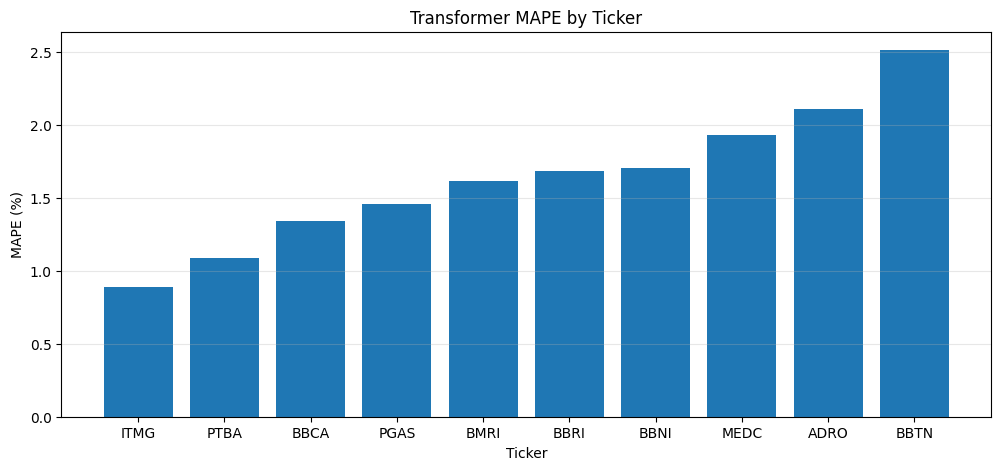

In [12]:
plot_df = results_df.sort_values("MAPE")

plt.figure(figsize=(12, 5))

plt.bar(
    plot_df["ticker"],
    plot_df["MAPE"]
)

plt.title("Transformer MAPE by Ticker")
plt.xlabel("Ticker")
plt.ylabel("MAPE (%)")
plt.grid(axis="y", alpha=0.3)

plt.show()

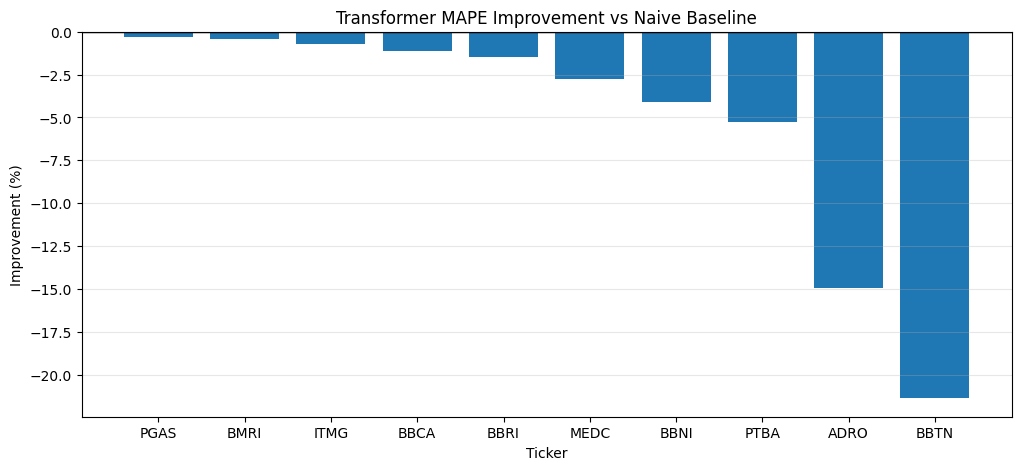

In [13]:
improvement_df = results_df.sort_values(
    "MAPE Improvement (%)",
    ascending=False
)

plt.figure(figsize=(12, 5))

plt.bar(
    improvement_df["ticker"],
    improvement_df["MAPE Improvement (%)"]
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)

plt.title("Transformer MAPE Improvement vs Naive Baseline")
plt.xlabel("Ticker")
plt.ylabel("Improvement (%)")
plt.grid(axis="y", alpha=0.3)

plt.show()

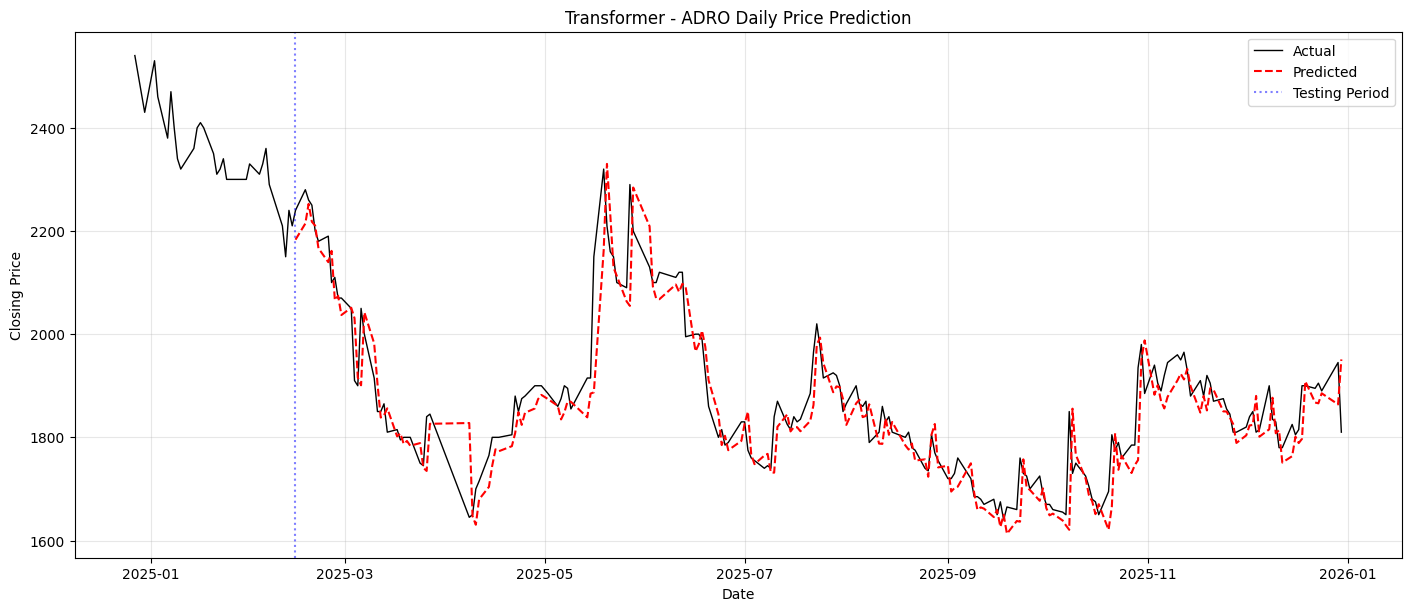

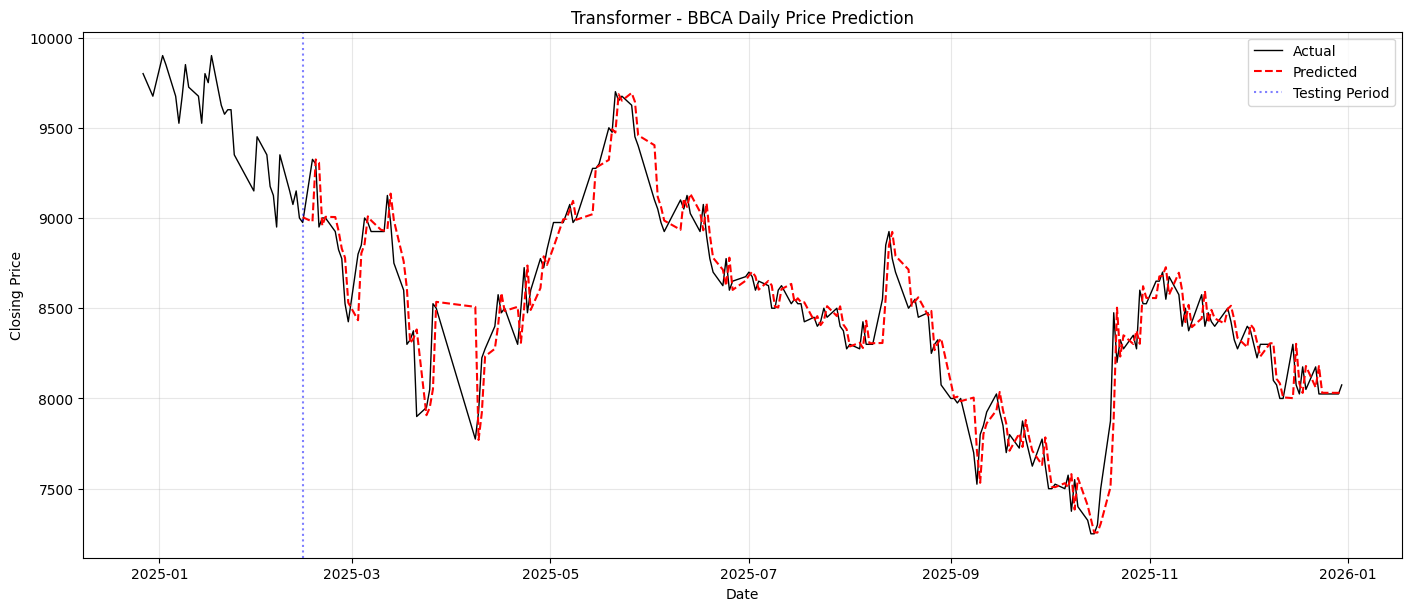

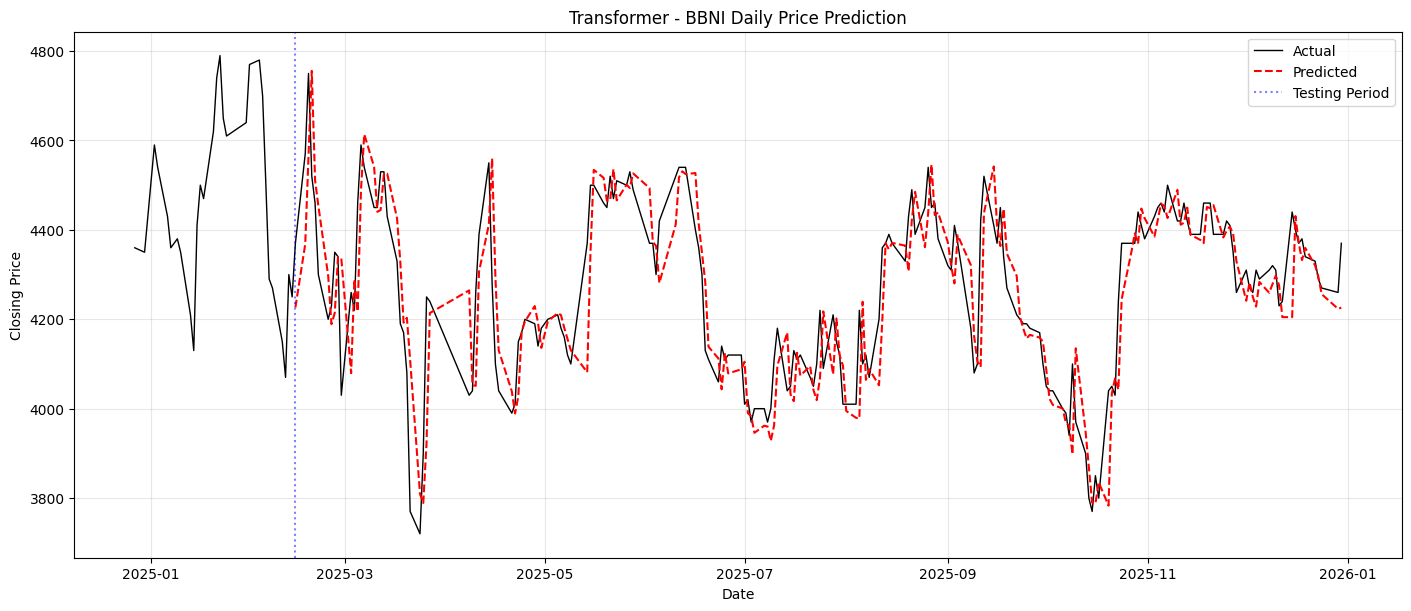

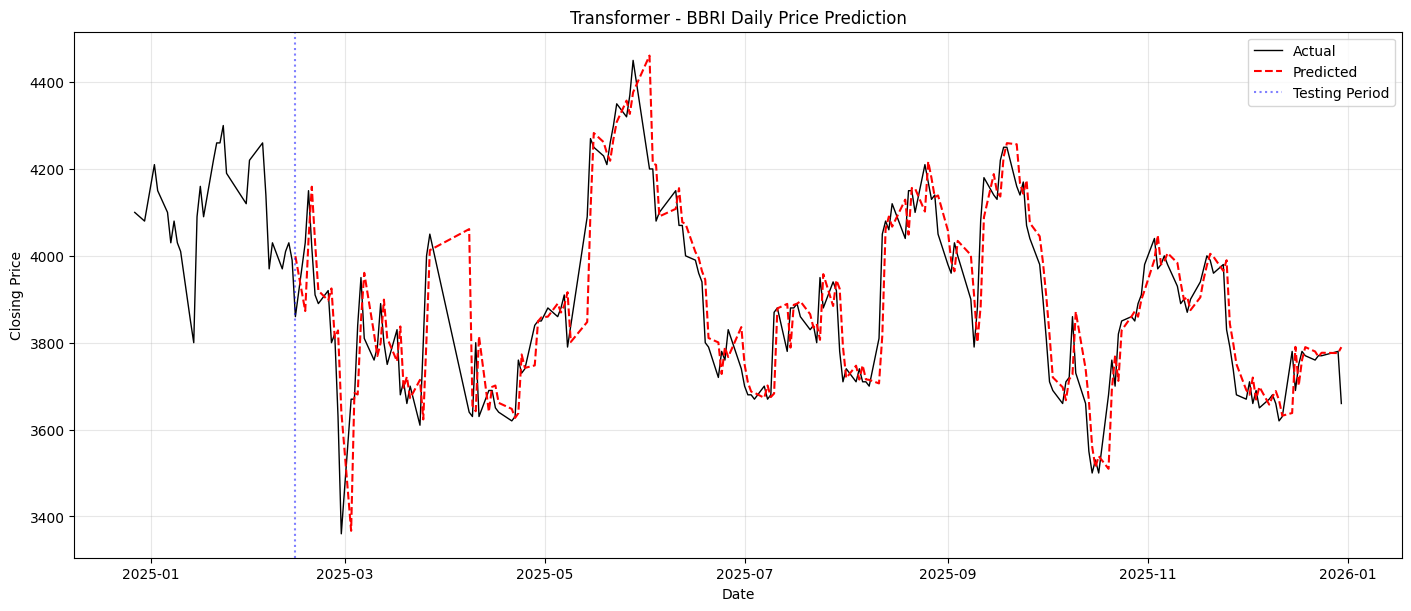

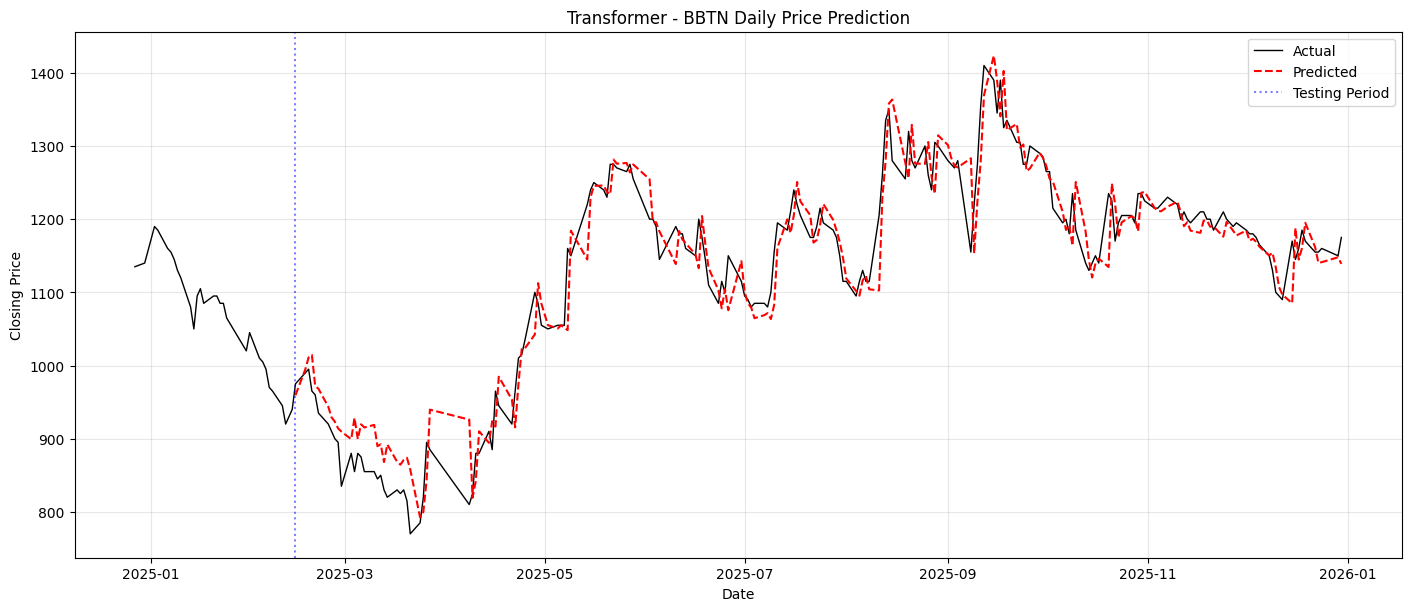

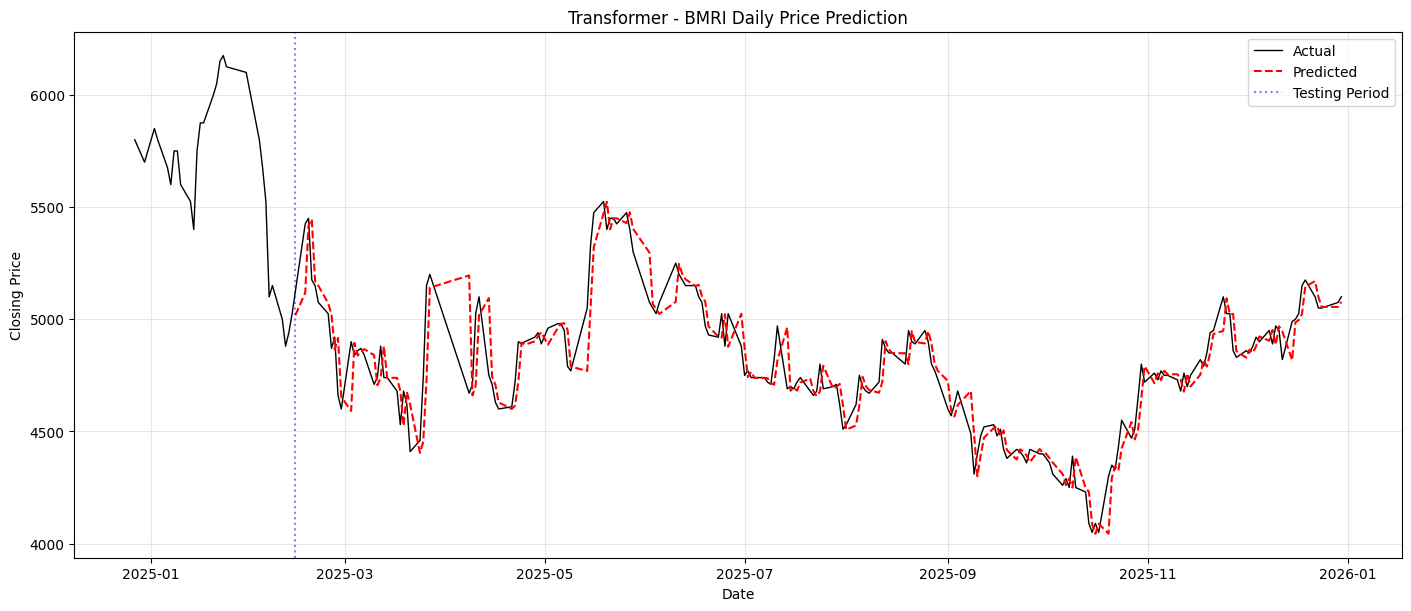

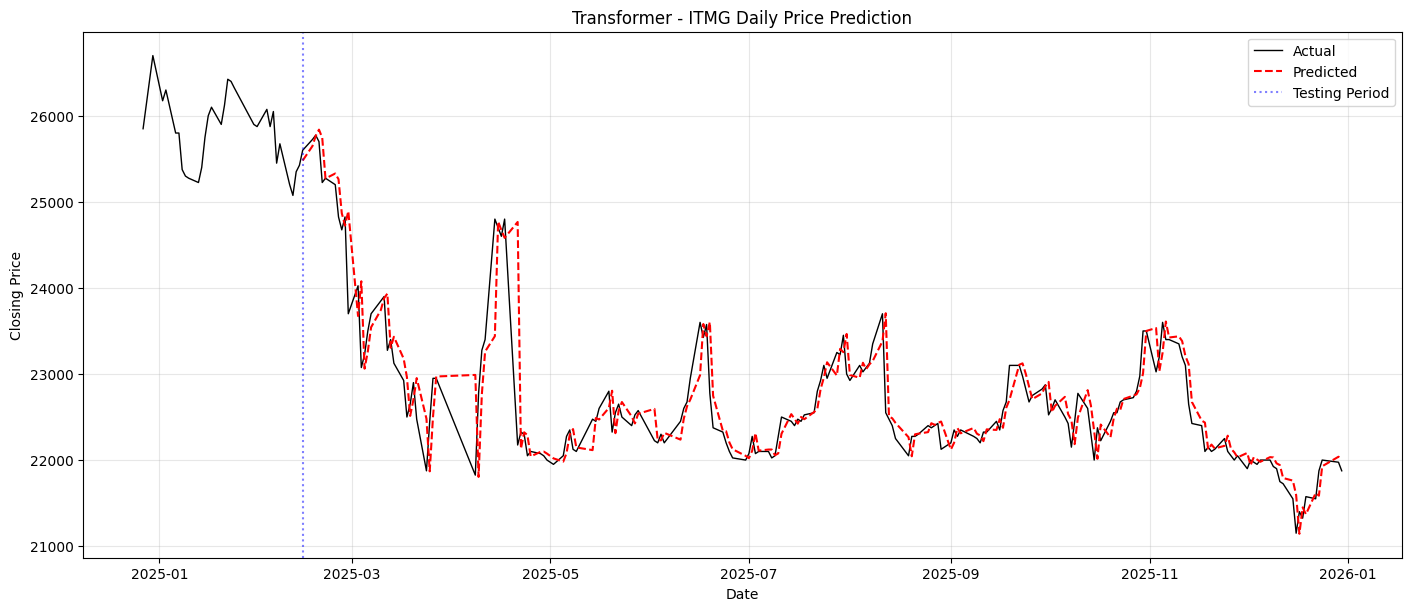

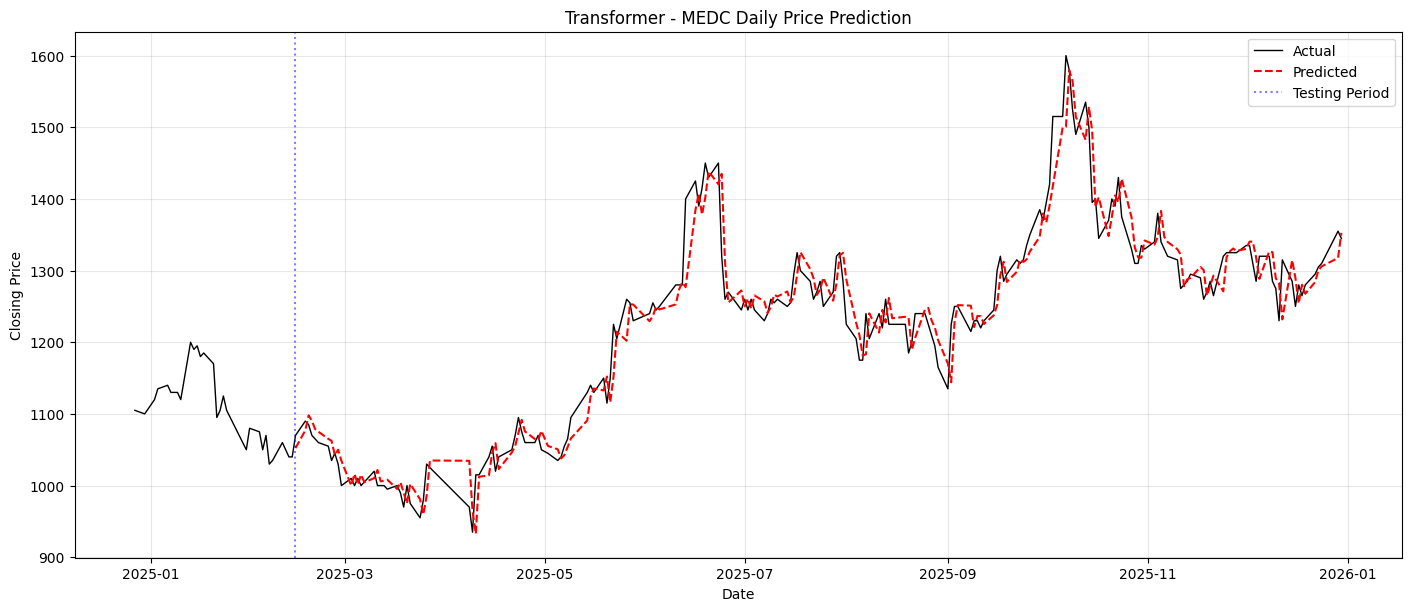

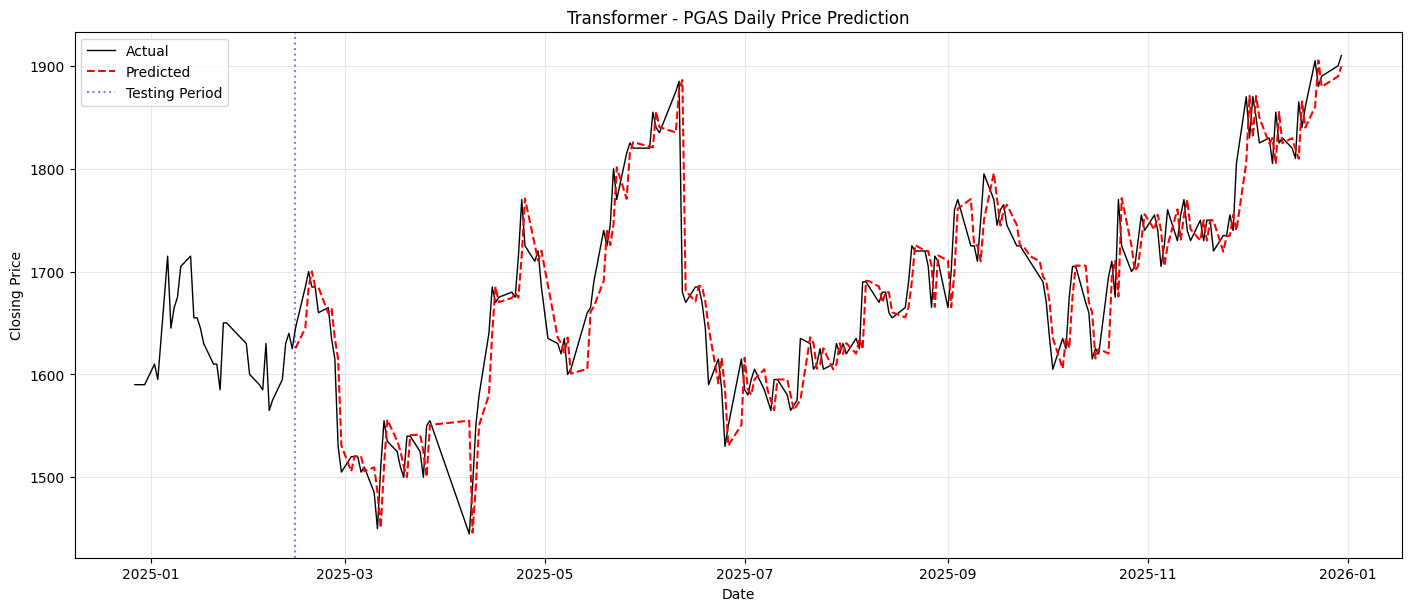

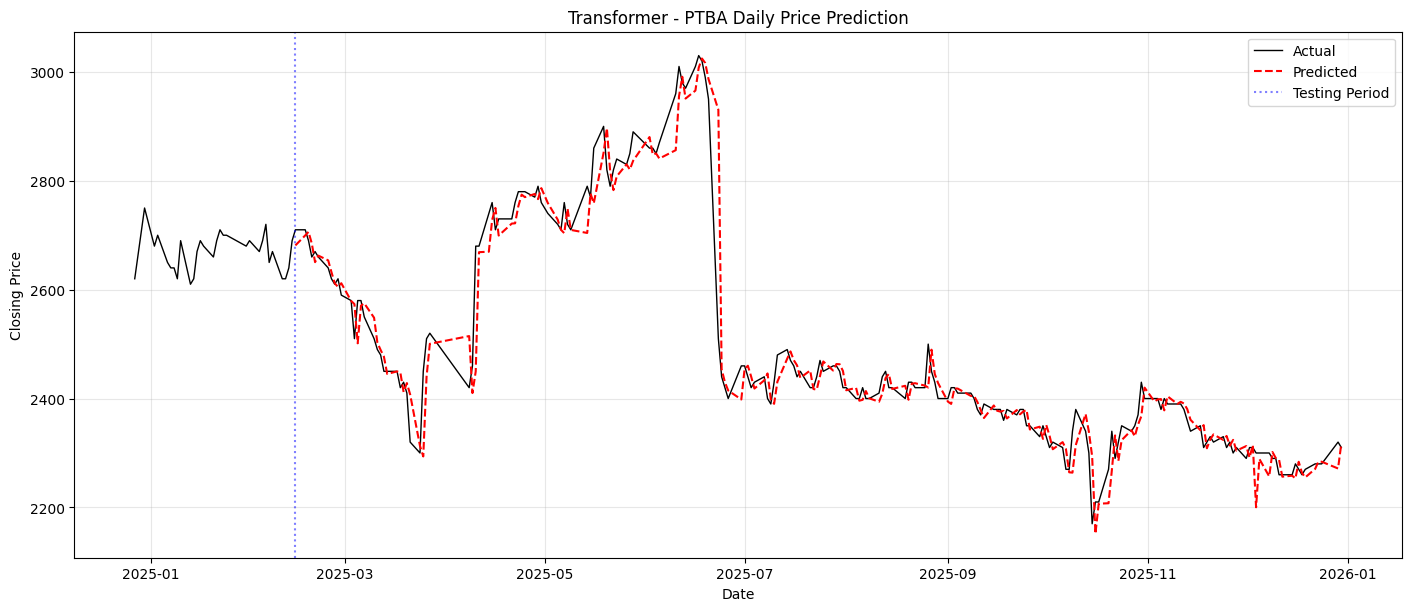

In [14]:
for ticker_name, data in predictions_store.items():

    dataset = data["dataset"]
    dates = data["dates"]
    predictions = data["predicted"]

    context_days = 30

    recent_history = dataset["close"].iloc[
        -(len(dates) + context_days):
    ]

    plt.figure(
        figsize=(14, 6),
        constrained_layout=True
    )

    plt.plot(
        recent_history.index,
        recent_history.values,
        label="Actual",
        color="black",
        linewidth=1
    )

    plt.plot(
        dates,
        predictions,
        label="Predicted",
        color="red",
        linewidth=1.5,
        linestyle="--"
    )

    plt.axvline(
        x=dates[0],
        color="blue",
        linestyle=":",
        alpha=0.5,
        label="Testing Period"
    )

    plt.title(
        f"Transformer - {ticker_name} Daily Price Prediction"
    )

    plt.xlabel("Date")
    plt.ylabel("Closing Price")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.show()

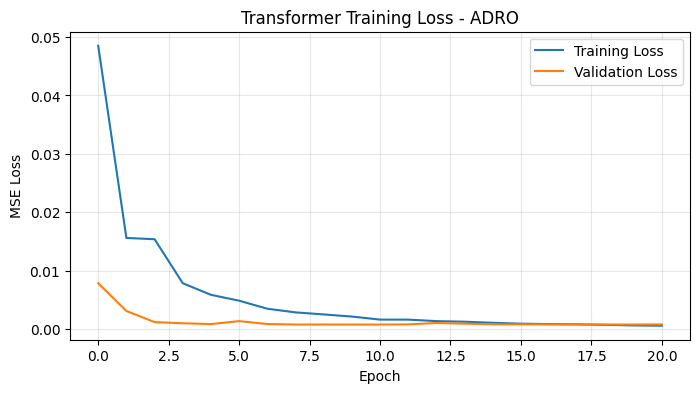

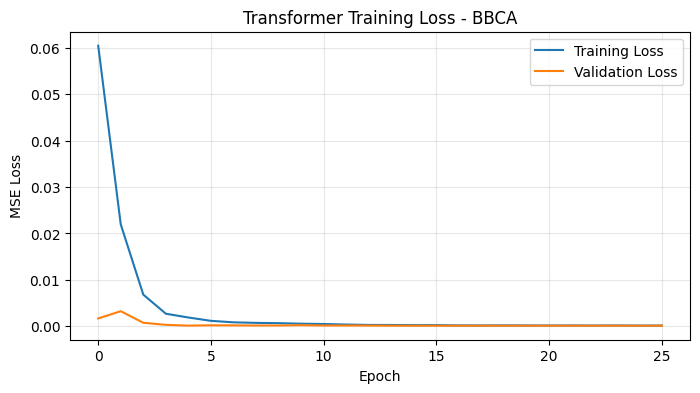

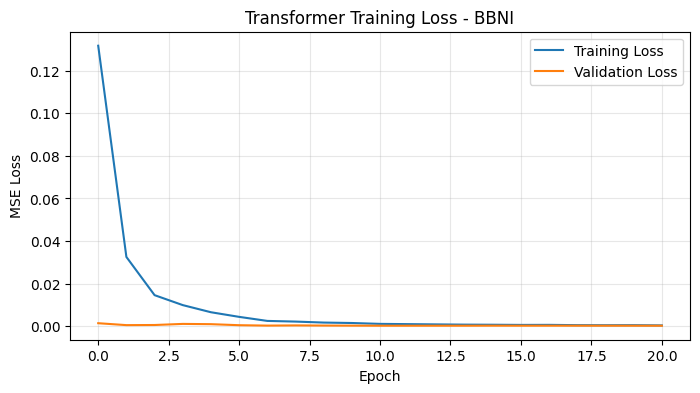

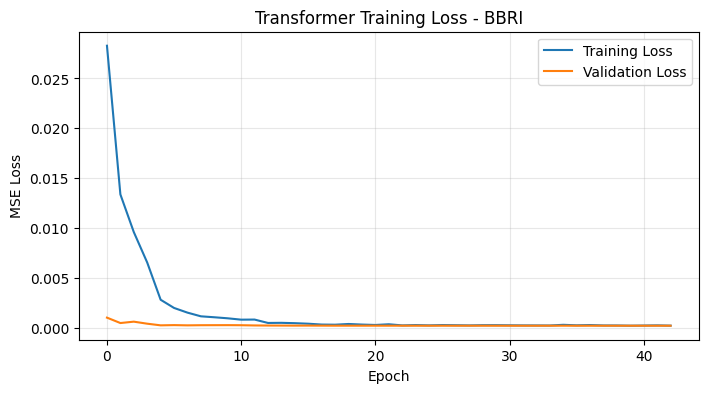

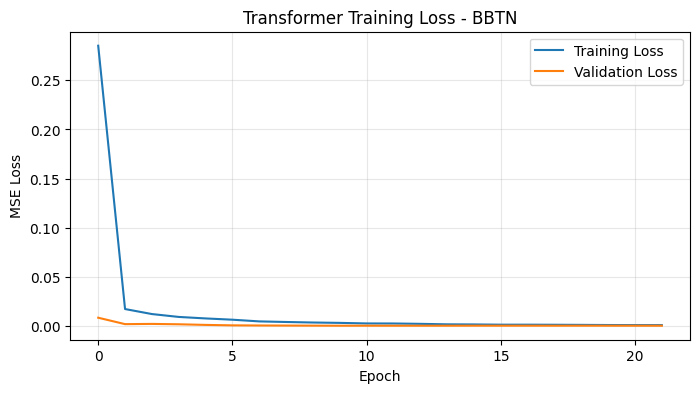

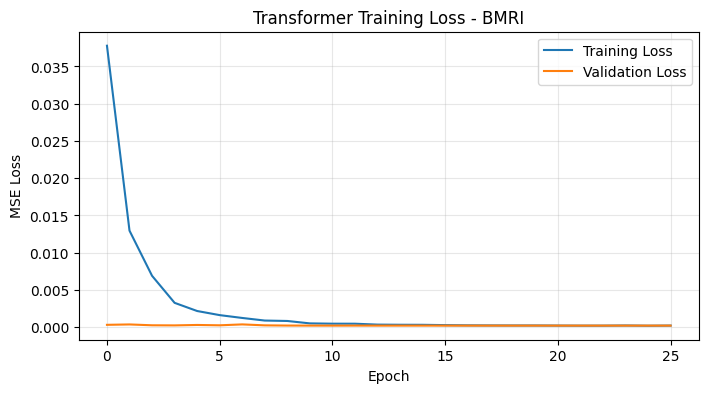

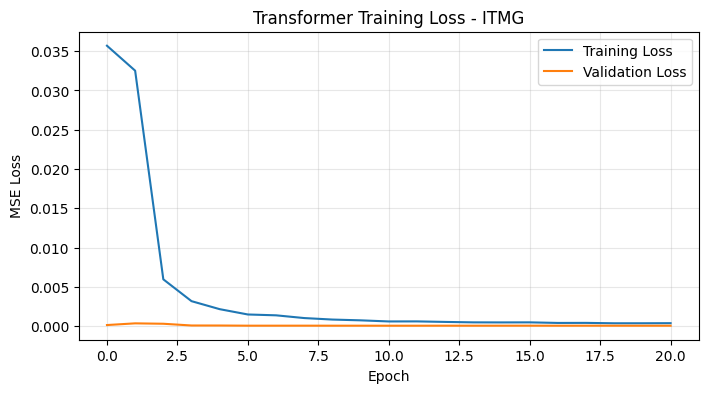

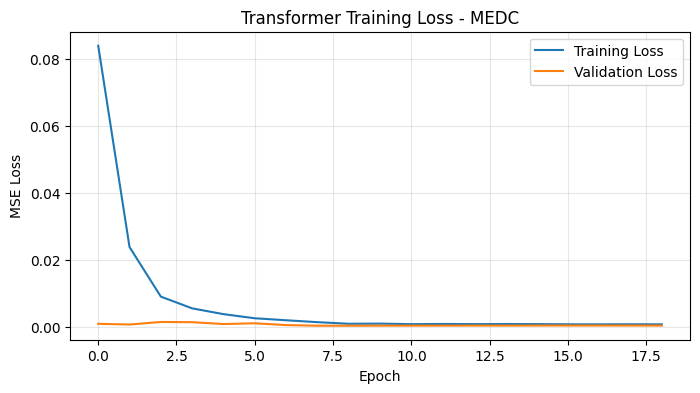

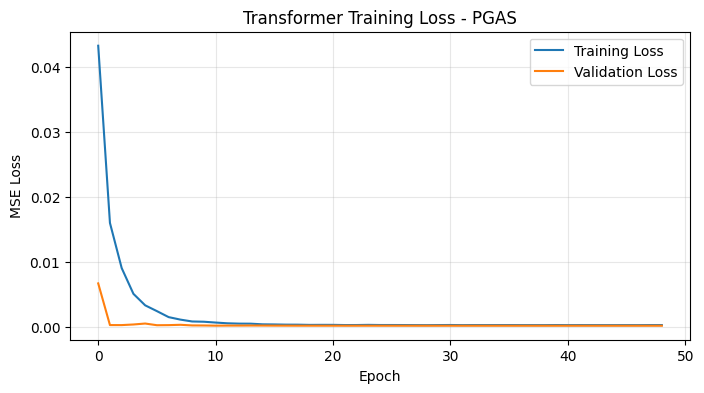

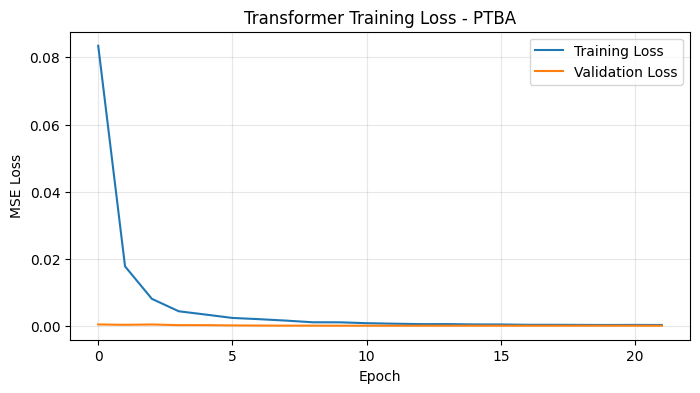

In [15]:
for ticker_name, history in histories.items():

    plt.figure(figsize=(8, 4))

    plt.plot(
        history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history["val_loss"],
        label="Validation Loss"
    )

    plt.title(
        f"Transformer Training Loss - {ticker_name}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()